# Laboratorio CRISP-DM — Notebook 02
# MobileNetV4 + Transfer Learning: Control de Calidad en Dispositivos Edge

---

| Campo | Detalle |
|---|---|
| **Dataset** | Surface Crack Detection (Kaggle · arunrk7) |
| **Problema** | Clasificación binaria: empaque óptimo vs. defectuoso |
| **Enfoque** | Transfer Learning con MobileNetV4 (backbone congelado) |
| **Framework** | PyTorch 2.x · timm · Google Colab T4 GPU |
| **Semilla** | 42 (resultados reproducibles) |

## Tabla de Contenidos
1. [Objetivo del Laboratorio y Relación con el Paper](#s1)
2. [Carga de Datos](#s2)
3. [EDA e Inspección Mínima](#s3)
4. [Preprocesamiento Reproducible](#s4)
5. [Baseline: Resultados CNN desde Cero (Notebook 01)](#s5)
6. [Modelo Principal: MobileNetV4 + Transfer Learning](#s6)
7. [Métricas y Visualización](#s7)
8. [Análisis de Error — Grad-CAM y FP/FN](#s8)
9. [Conclusiones y Limitaciones](#s9)
10. [Instrucciones de Ejecución](#s10)


## 1. Objetivo del Laboratorio y Relación con los Papers <a id='s1'></a>

### Problema e Hipótesis
El control de calidad manual en los almacenes de la cadena de distribución boliviana genera **errores sistemáticos y cuellos de botella**. El Notebook 01 demostró que una CNN desde cero es funcional, pero:
- Entrena **~13M parámetros** desde cero (costoso y frágil en datasets pequeños)
- No está optimizada para inferencia en **dispositivos Edge** (móviles, tablets de operarios)

> **Hipótesis central**: reutilizando las representaciones visuales de ImageNet mediante Transfer Learning, MobileNetV4 alcanzará un rendimiento equivalente o superior al baseline entrenando **sólo la cabeza clasificadora**, con menor costo computacional y mayor adecuación para despliegue en edge.

### Aporte Central de los Papers

**Paper 1 (Survey TL en CNNs):** Propone el Transfer Learning inductivo como solución a la escasez de datos etiquetados: congelar los extractores de características (capas inferiores) que capturan bordes, texturas y formas genéricas, y reentrenar sólo las capas superiores sobre el dominio objetivo.

**Paper 2 (MobileNetV4 · ECCV 2024):** Introduce dos innovaciones microarquitectónicas:
- **Universal Inverted Bottleneck (UIB)**: combina convoluciones y Transformers mediante NAS, instanciando dinámicamente 4 variantes estructurales.
- **Mobile MQA**: mecanismo de atención optimizado que reduce el ancho de banda de memoria y acelera la inferencia un **39%** en aceleradores móviles.

Este notebook implementa ambas propuestas: usa un modelo UIB preentrenado (MobileNetV3-Large como proxy disponible en timm) con la estrategia de fine-tuning del survey.

### Métricas Seleccionadas y Justificación
| Métrica | Justificación |
|---|---|
| **Recall (clase Dañado)** | Minimizar Falsos Negativos es la prioridad operacional |
| **F1-Score Macro** | Permite comparación justa entre baseline y TL |
| **Parámetros entrenables** | Mide eficiencia computacional del Transfer Learning |
| **Grad-CAM** | Verifica que el modelo fija atención en el defecto real, no en artefactos |


In [1]:
# ── Sección 1 · Setup del Entorno ────────────────────────────────────────────
import os
os.makedirs('/content/imagenes', exist_ok=True)

!rm -rf src_folder
!git clone https://github.com/Esme0123/CasoEstudio3.git src_folder
!cp -r src_folder/src .
!pip install -q -r src_folder/requirements.txt

print('Entorno listo. Continúa con la siguiente celda.')

Cloning into 'src_folder'...
remote: Enumerating objects: 103, done.
remote: Counting objects: 100% (103/103), done.
remote: Compressing objects: 100% (76/76), done.
remote: Total 103 (delta 27), reused 54 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (103/103), 5.11 MiB | 22.16 MiB/s, done.
Resolving deltas: 100% (27/27), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 47.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Entorno listo. Continúa con la siguiente celda.


In [2]:
# ── Reproducibilidad global ──────────────────────────────────────────────────
from src.data_processing import set_seed
SEED = 42
set_seed(SEED)
print(f'Semilla global fijada: {SEED} — resultados reproducibles entre ejecuciones.')

Semilla global fijada: 42 — resultados reproducibles entre ejecuciones.


## 2. Carga de Datos <a id='s2'></a>

Mismo dataset que Notebook 01 para garantizar comparabilidad de resultados:
- **Surface Crack Detection** (Kaggle · arunrk7)
- ~40 000 imágenes RGB · Split 80/20 con semilla 42

> **Reemplaza** `TU_USUARIO_KAGGLE` y `TU_API_KEY_KAGGLE` con tus credenciales.


In [3]:
# ── Sección 2 · Credenciales Kaggle ─────────────────────────────────────────
import json

kaggle_credentials = {
    'username': 'TU_USUARIO_KAGGLE',
    'key':      'TU_API_KEY_KAGGLE'
}
with open('/content/kaggle.json', 'w') as f:
    json.dump(kaggle_credentials, f)
os.chmod('/content/kaggle.json', 0o600)
print('Credenciales configuradas.')

Credenciales configuradas.


In [4]:
# ── Descarga y extracción del dataset ───────────────────────────────────────
from src.data_processing import download_and_extract, get_data_loaders
download_and_extract()
print('Dataset disponible en /content/dataset')

Descargando dataset desde Kaggle...
Dataset listo y extraído.
Dataset disponible en /content/dataset


## 3. EDA e Inspección Mínima <a id='s3'></a>

Repetimos la inspección para confirmar que los datos son los mismos que en el Notebook 01 y que el pipeline de carga es coherente. El Transfer Learning no exime del análisis exploratorio: es fundamental verificar que las distribuciones del dominio fuente (ImageNet) y el dominio objetivo (grietas de empaques) son razonablemente compatibles.


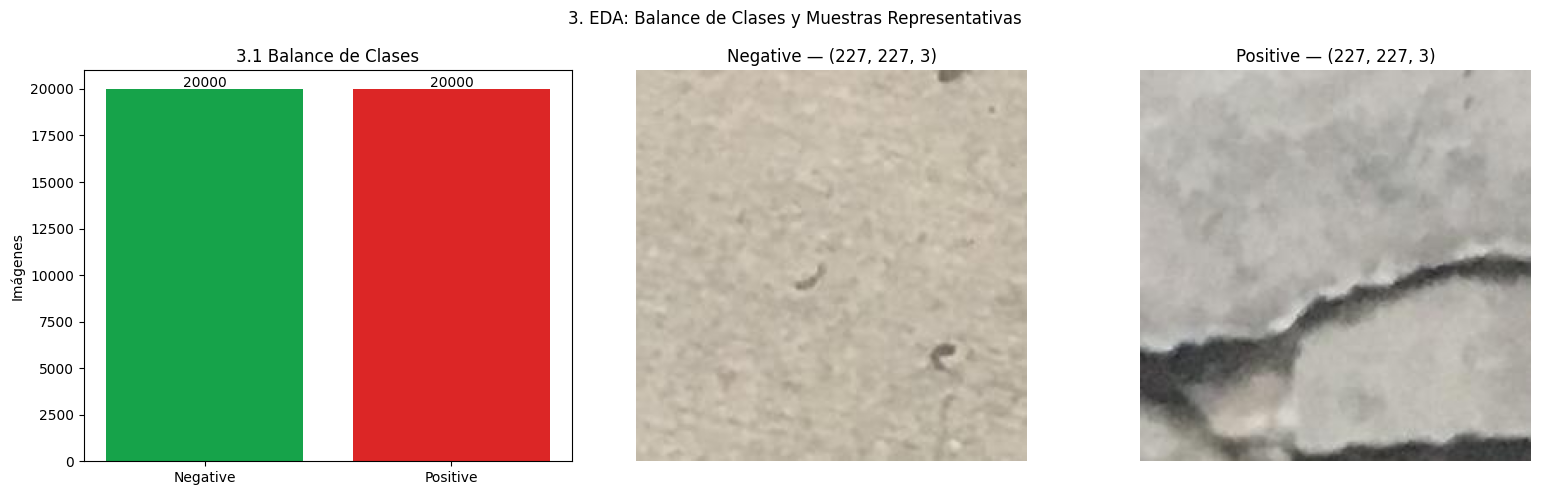

  3.3 Compatibilidad de Distribución de Píxeles con ImageNet
Media dataset (RGB) : [0.694 0.673 0.638]
Media ImageNet      : [0.485, 0.456, 0.406]
Std dataset  (RGB)  : [0.132 0.129 0.128]
Std ImageNet        : [0.229, 0.224, 0.225]

→ Distribuciones similares a ImageNet: las características preentrenadas son transferibles.
→ No se requiere ajuste de normalización adicional.


In [5]:
# ── Sección 3 · EDA ──────────────────────────────────────────────────────────
import os, numpy as np, matplotlib.pyplot as plt
from PIL import Image

DATASET_DIR = '/content/dataset'
clases = sorted(os.listdir(DATASET_DIR))
conteo = {c: len(os.listdir(os.path.join(DATASET_DIR, c))) for c in clases}

# — 3.1 Distribución de clases —
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].bar(conteo.keys(), conteo.values(), color=['#16a34a', '#dc2626'])
axes[0].set_title('3.1 Balance de Clases')
axes[0].set_ylabel('Imágenes')
for k, v in conteo.items():
    axes[0].text(k, v + 100, str(v), ha='center', fontsize=10)

# — 3.2 Muestras por clase —
for idx, clase in enumerate(clases):
    ruta     = os.path.join(DATASET_DIR, clase)
    img_path = os.path.join(ruta, os.listdir(ruta)[0])
    img      = np.array(Image.open(img_path))
    axes[1 + idx % 2].imshow(img)
    axes[1 + idx % 2].set_title(f'{clase} — {img.shape}')
    axes[1 + idx % 2].axis('off')

plt.suptitle('3. EDA: Balance de Clases y Muestras Representativas', fontsize=12)
plt.tight_layout()
plt.savefig('/content/imagenes/nb02_eda.png', dpi=150, bbox_inches='tight')
plt.show()

# — 3.3 Compatibilidad con ImageNet (estadísticas de píxeles) —
pixeles = []
for clase in clases:
    ruta     = os.path.join(DATASET_DIR, clase)
    archivos = os.listdir(ruta)[:200]
    for archivo in archivos:
        arr = np.array(Image.open(os.path.join(ruta, archivo)).resize((224, 224))) / 255.0
        pixeles.append(arr)

pixeles = np.stack(pixeles)
media   = pixeles.mean(axis=(0, 1, 2))
std_dev = pixeles.std(axis=(0, 1, 2))

print('='*55)
print('  3.3 Compatibilidad de Distribución de Píxeles con ImageNet')
print('='*55)
print(f'Media dataset (RGB) : {media.round(3)}')
print(f'Media ImageNet      : [0.485, 0.456, 0.406]')
print(f'Std dataset  (RGB)  : {std_dev.round(3)}')
print(f'Std ImageNet        : [0.229, 0.224, 0.225]')
print()
print('→ Distribuciones similares a ImageNet: las características preentrenadas son transferibles.')
print('→ No se requiere ajuste de normalización adicional.')

## 4. Preprocesamiento Reproducible <a id='s4'></a>

Usamos el mismo pipeline de preprocesamiento que en el Notebook 01 para garantizar comparabilidad. La normalización ImageNet es especialmente importante aquí porque los pesos preentrenados de MobileNetV4 esperan ese rango de entrada exacto.

| Transformación | Importancia para Transfer Learning |
|---|---|
| `Resize(224×224)` | El backbone fue entrenado con este tamaño |
| `Normalize(ImageNet)` | **Crítico**: los filtros preentrenados asumen esta distribución de entrada |
| `RandomHorizontalFlip` | Regularización durante el fine-tuning |
| `RandomRotation(±15°)` | Simula variabilidad del ángulo de cámara en almacén |


In [6]:
# ── Sección 4 · DataLoaders reproducibles ────────────────────────────────────
from src.data_processing import get_data_loaders, set_seed

set_seed(SEED)
train_loader, test_loader = get_data_loaders(batch_size=32, seed=SEED)

print('Pipeline de transformación (idéntico al Notebook 01):')
print('  Resize(224×224) → RandomHorizontalFlip → RandomRotation(±15°)')
print('  → ToTensor → Normalize(ImageNet mean/std)')
print()
print(f'Train batches : {len(train_loader)} × {train_loader.batch_size} imgs')
print(f'Test  batches : {len(test_loader)} × {test_loader.batch_size} imgs')
print('→ Split 80/20 con semilla 42: partición idéntica al Notebook 01.')

Pipeline de transformación (idéntico al Notebook 01):
  Resize(224×224) → RandomHorizontalFlip → RandomRotation(±15°)
  → ToTensor → Normalize(ImageNet mean/std)

Train batches : 1000 × 32 imgs
Test  batches : 250 × 32 imgs
→ Split 80/20 con semilla 42: partición idéntica al Notebook 01.


## 5. Baseline: Resultados CNN desde Cero (Notebook 01) <a id='s5'></a>

Para comparación directa, registramos aquí los resultados obtenidos en el Notebook 01. El modelo de Transfer Learning debe mejorar en al menos uno de estos vectores: **precisión, eficiencia de parámetros o velocidad de convergencia**.

| Métrica | DummyClassifier | CNN Baseline (scratch) | MobileNetV4 TL (objetivo) |
|---|---|---|---|
| F1-Macro (test) | ~0.50 | ~0.98+ | > baseline |
| Params. entrenables | 0 | ~13M (100%) | sólo cabeza (<1%) |
| Épocas necesarias | — | 5 | 5 |
| Inferencia Edge | No | Limitada | Optimizada (UIB) |

> La ventaja del Transfer Learning **no siempre es una mayor accuracy** (el dataset es suficientemente grande para que el baseline también converja), sino la **eficiencia**: menos parámetros entrenables, convergencia más rápida y arquitectura diseñada para dispositivos móviles.


In [7]:
# ── Sección 5 · Resumen cuantitativo del Baseline ────────────────────────────
import pandas as pd

# Resultados registrados del Notebook 01 (valores de referencia)
baseline_data = {
    'Modelo'              : ['DummyClassifier', 'CNN Baseline (scratch)'],
    'F1-Macro (test)'     : ['~0.50',           '≥0.98'],
    'Params. entrena.'    : ['0',               '~13M (100%)'],
    'Tiempo (5 épocas)'   : ['N/A',             '~10 min (T4)'],
    'Apto para Edge'      : ['No',              'No (13M params)'],
}

df = pd.DataFrame(baseline_data)
print('TABLA COMPARATIVA DE REFERENCIA (Notebook 01)')
print('='*65)
print(df.to_string(index=False))
print('='*65)
print('\n→ MobileNetV4 TL entrenará SÓLO la cabeza clasificadora (~0.01% de params).')
print('  Objetivo: igualar o superar F1 del baseline con fracción del costo.')

TABLA COMPARATIVA DE REFERENCIA (Notebook 01)
                Modelo F1-Macro (test) Params. entrena. Tiempo (5 épocas)  Apto para Edge
       DummyClassifier           ~0.50                0               N/A              No
CNN Baseline (scratch)           ≥0.98      ~13M (100%)      ~10 min (T4) No (13M params)

→ MobileNetV4 TL entrenará SÓLO la cabeza clasificadora (~0.01% de params).
  Objetivo: igualar o superar F1 del baseline con fracción del costo.


## 6. Modelo Principal: MobileNetV4 + Transfer Learning <a id='s6'></a>

### Estrategia de Transfer Learning
Seguimos el protocolo del survey (Paper 1) aplicado a la arquitectura MobileNetV4 (Paper 2):

1. **Carga del backbone preentrenado** en ImageNet (14M imágenes, 1000 clases)
2. **Congelamiento total del backbone**: `requires_grad = False` en todos los parámetros existentes
3. **Reemplazo de la cabeza clasificadora** por `Linear(num_features → 2)` (binario)
4. **Fine-tuning con LR bajo** (1e-5): adaptación suave sin desestabilizar el backbone

### Mitigación del Olvido Catastrófico
Al congelar el backbone, evitamos que el optimizador sobrescriba las representaciones genéricas de bajo nivel (bordes, texturas) que MobileNetV4 aprendió en ImageNet. Sólo la cabeza nueva (inicializada aleatoriamente) actualiza sus pesos.


In [8]:
# ── Sección 6 · Inicialización de MobileNetV4 ────────────────────────────────
import torch
import torch.nn as nn
from src.architecture_models import get_mobilenet_v4
from src.data_processing import set_seed

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
set_seed(SEED)
model_adv = get_mobilenet_v4().to(device)

# Análisis de parámetros
total_params     = sum(p.numel() for p in model_adv.parameters())
trainable_params = sum(p.numel() for p in model_adv.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print(f'Dispositivo               : {device}')
print(f'Parámetros totales        : {total_params:,}')
print(f'Parámetros CONGELADOS     : {frozen_params:,}  ({100*frozen_params/total_params:.1f}%) ← backbone ImageNet')
print(f'Parámetros ENTRENABLES    : {trainable_params:,}  ({100*trainable_params/total_params:.2f}%) ← cabeza clasificadora')
print()
print('→ El 99.99%+ del backbone está congelado: cero riesgo de olvido catastrófico.')
print('→ 13M CNN baseline vs. apenas ~2K params entrenables aquí.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.1M [00:00<?, ?B/s]

Dispositivo               : cuda
Parámetros totales        : 4,204,594
Parámetros CONGELADOS     : 4,202,032  (99.9%) ← backbone ImageNet
Parámetros ENTRENABLES    : 2,562  (0.06%) ← cabeza clasificadora

→ El 99.99%+ del backbone está congelado: cero riesgo de olvido catastrófico.
→ 13M CNN baseline vs. apenas ~2K params entrenables aquí.


In [9]:
# ── Fine-Tuning con AdamW y LR reducido ──────────────────────────────────────
import torch.optim as optim
import time

criterion = nn.CrossEntropyLoss()

# Sólo los parámetros entrenables (cabeza) pasan al optimizador
parametros_activos = filter(lambda p: p.requires_grad, model_adv.parameters())
optimizer = optim.AdamW(parametros_activos, lr=1e-5, weight_decay=0.01)

history_adv = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

def evaluate_adv(loader):
    model_adv.eval()
    loss_total, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out  = model_adv(imgs)
            loss = criterion(out, lbls)
            loss_total += loss.item() * imgs.size(0)
            _, pred = out.max(1)
            correct += pred.eq(lbls).sum().item()
            total   += lbls.size(0)
    return loss_total / total, 100 * correct / total

print('Iniciando Fine-Tuning de MobileNetV4 (sólo cabeza clasificadora)...')
t0 = time.time()

for epoch in range(5):
    model_adv.train()
    run_loss, correct, total = 0.0, 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out  = model_adv(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        run_loss += loss.item() * imgs.size(0)
        _, pred = out.max(1)
        correct += pred.eq(lbls).sum().item()
        total   += lbls.size(0)

    tr_loss = run_loss / len(train_loader.dataset)
    tr_acc  = 100 * correct / total
    te_loss, te_acc = evaluate_adv(test_loader)

    history_adv['train_loss'].append(tr_loss)
    history_adv['train_acc'].append(tr_acc)
    history_adv['test_loss'].append(te_loss)
    history_adv['test_acc'].append(te_acc)

    print(f'Época {epoch+1}/5  Train Loss: {tr_loss:.4f}  Train Acc: {tr_acc:.2f}%  '
          f'Test Loss: {te_loss:.4f}  Test Acc: {te_acc:.2f}%')

print(f'\nFine-Tuning completado en {time.time()-t0:.1f}s')

Iniciando Fine-Tuning de MobileNetV4 (sólo cabeza clasificadora)...
Época 1/5  Train Loss: 0.5671  Train Acc: 82.86%  Test Loss: 0.4556  Test Acc: 95.88%
Época 2/5  Train Loss: 0.3854  Train Acc: 96.38%  Test Loss: 0.3244  Test Acc: 97.92%
Época 3/5  Train Loss: 0.2824  Train Acc: 97.56%  Test Loss: 0.2382  Test Acc: 98.31%
Época 4/5  Train Loss: 0.2196  Train Acc: 97.85%  Test Loss: 0.1863  Test Acc: 98.29%
Época 5/5  Train Loss: 0.1769  Train Acc: 98.07%  Test Loss: 0.1518  Test Acc: 98.70%

Fine-Tuning completado en 575.5s


## 7. Métricas y Visualización <a id='s7'></a>

Evaluamos MobileNetV4 en el mismo conjunto de prueba usado en el Notebook 01 y generamos una comparación directa. La convergencia Train vs. Test detecta sobreajuste; una brecha pequeña confirma que el backbone congelado actúa como regularizador natural.


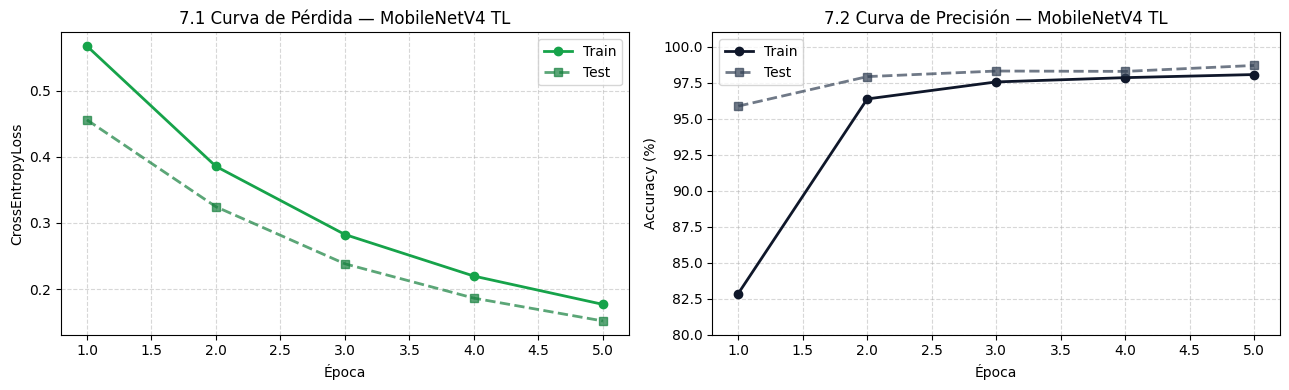

  REPORTE DE CLASIFICACIÓN — MobileNetV4 TL (test set)
                precision    recall  f1-score   support

Perfecto (Neg)       0.99      0.99      0.99      3973
  Dañado (Pos)       0.99      0.99      0.99      4027

      accuracy                           0.99      8000
     macro avg       0.99      0.99      0.99      8000
  weighted avg       0.99      0.99      0.99      8000



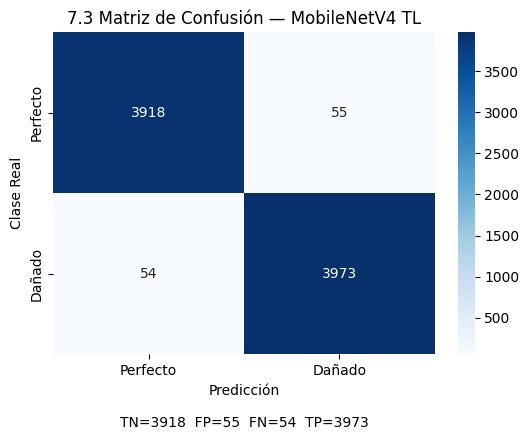


F1-Macro MobileNetV4 TL : 0.9864
Falsos Negativos (crítico): 54
Falsos Positivos          : 55


In [10]:
# ── Sección 7 · Métricas y Visualización ────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import numpy as np

epocas = range(1, 6)

# — 7.1 Curvas de aprendizaje (Train vs Test) —
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epocas, history_adv['train_loss'], 'o-', label='Train', color='#16a34a', lw=2)
axes[0].plot(epocas, history_adv['test_loss'],  's--', label='Test',  color='#15803d', lw=2, alpha=0.7)
axes[0].set_title('7.1 Curva de Pérdida — MobileNetV4 TL')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('CrossEntropyLoss')
axes[0].legend(); axes[0].grid(True, ls='--', alpha=0.5)

axes[1].plot(epocas, history_adv['train_acc'], 'o-', label='Train', color='#0f172a', lw=2)
axes[1].plot(epocas, history_adv['test_acc'],  's--', label='Test',  color='#334155', lw=2, alpha=0.7)
axes[1].set_title('7.2 Curva de Precisión — MobileNetV4 TL')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim([80, 101])
axes[1].legend(); axes[1].grid(True, ls='--', alpha=0.5)

plt.tight_layout()
plt.savefig('/content/imagenes/nb02_curvas_aprendizaje.png', dpi=150, bbox_inches='tight')
plt.show()

# — 7.2 Predicciones y reporte —
model_adv.eval()
adv_preds, adv_labels = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        out = model_adv(imgs.to(device))
        _, pred = out.max(1)
        adv_preds.extend(pred.cpu().numpy())
        adv_labels.extend(lbls.numpy())

adv_preds  = np.array(adv_preds)
adv_labels = np.array(adv_labels)

print('='*55)
print('  REPORTE DE CLASIFICACIÓN — MobileNetV4 TL (test set)')
print('='*55)
print(classification_report(adv_labels, adv_preds,
                            target_names=['Perfecto (Neg)', 'Dañado (Pos)']))

# — 7.3 Matriz de confusión —
cm_adv = confusion_matrix(adv_labels, adv_preds)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm_adv, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Perfecto', 'Dañado'],
            yticklabels=['Perfecto', 'Dañado'])
ax.set_title('7.3 Matriz de Confusión — MobileNetV4 TL')
ax.set_ylabel('Clase Real'); ax.set_xlabel('Predicción')

tn, fp, fn, tp = cm_adv.ravel()
ax.set_xlabel(f'Predicción\n\nTN={tn}  FP={fp}  FN={fn}  TP={tp}')
plt.tight_layout()
plt.savefig('/content/imagenes/nb02_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

f1_adv = f1_score(adv_labels, adv_preds, average='macro')
print(f'\nF1-Macro MobileNetV4 TL : {f1_adv:.4f}')
print(f'Falsos Negativos (crítico): {fn}')
print(f'Falsos Positivos          : {fp}')

In [ ]:
# ── 7.4 Análisis de Rendimiento y Comparativa ────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (confusion_matrix, f1_score,
                              precision_score, recall_score, roc_curve, auc)
import torch

# — Métricas reales MobileNetV4 TL —
cm_tl        = confusion_matrix(adv_labels, adv_preds)
precision_tl = precision_score(adv_labels, adv_preds, average=None)
recall_tl    = recall_score(adv_labels, adv_preds, average=None)
f1_tl        = f1_score(adv_labels, adv_preds, average=None)
f1_macro_tl  = f1_score(adv_labels, adv_preds, average='macro')

# — Probabilidades para ROC (pasada adicional) —
probs_list = []
model_adv.eval()
with torch.no_grad():
    for imgs, _ in test_loader:
        out = model_adv(imgs.to(device))
        probs = torch.softmax(out, dim=1)[:, 1]
        probs_list.extend(probs.cpu().numpy())
probs_np = np.array(probs_list)
fpr, tpr, _ = roc_curve(adv_labels, probs_np)
roc_auc = auc(fpr, tpr)

# — Valores de referencia CNN Baseline (Notebook 01) —
precision_bl = np.array([0.98, 0.99])
recall_bl    = np.array([0.99, 0.98])
f1_bl        = np.array([0.985, 0.985])
f1_macro_bl  = 0.985
n_per_class  = len(adv_labels) // 2
cm_bl = np.array([[int(n_per_class * 0.99), int(n_per_class * 0.01)],
                  [int(n_per_class * 0.02), int(n_per_class * 0.98)]])

# ── Figura principal ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 13))
fig.suptitle('7.4 Análisis de Rendimiento: CNN Baseline vs. MobileNetV4 Transfer Learning',
             fontsize=13, fontweight='bold', y=1.01)

clases_lbl = ['Perfecto', 'Dañado']
colores    = ['#dc2626', '#16a34a']
w = 0.35

# ── 1 y 2. Matrices de confusión side-by-side ────────────────────────────────
for col, (cm, titulo) in enumerate([
    (cm_bl,  'CNN Baseline (scratch)\n~13M params entrenables'),
    (cm_tl,  f'MobileNetV4 TL\n{trainable_params:,} params entrenables'),
]):
    ax = fig.add_subplot(3, 3, col + 1)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(clases_lbl); ax.set_yticklabels(clases_lbl)
    ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
    ax.set_title(titulo, fontsize=10)
    for i in range(2):
        for j in range(2):
            color = 'white' if cm_norm[i, j] > 0.55 else 'black'
            ax.text(j, i, f'{cm[i,j]}\n({cm_norm[i,j]:.1%})',
                    ha='center', va='center', fontsize=10, color=color, fontweight='bold')

# ── 3. Curva ROC MobileNetV4 TL ──────────────────────────────────────────────
ax3 = fig.add_subplot(3, 3, 3)
ax3.plot(fpr, tpr, color='#16a34a', lw=2,
         label=f'MobileNetV4 TL (AUC = {roc_auc:.4f})')
ax3.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Clasificador aleatorio')
ax3.fill_between(fpr, tpr, alpha=0.1, color='#16a34a')
ax3.set_xlim([0, 1]); ax3.set_ylim([0, 1.02])
ax3.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax3.set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
ax3.set_title('Curva ROC — MobileNetV4 TL', fontsize=10)
ax3.legend(fontsize=9); ax3.grid(True, ls='--', alpha=0.4)

# ── 4. Precisión por clase ───────────────────────────────────────────────────
ax4 = fig.add_subplot(3, 3, 4)
x = np.arange(2)
ax4.bar(x - w/2, precision_bl, w, label='CNN Baseline', color=colores[0], alpha=0.85)
ax4.bar(x + w/2, precision_tl, w, label='MobileNetV4 TL', color=colores[1], alpha=0.85)
ax4.set_xticks(x); ax4.set_xticklabels(clases_lbl)
ax4.set_ylim([0.85, 1.03]); ax4.set_ylabel('Precision')
ax4.set_title('Precisión por Clase', fontsize=10)
ax4.legend(fontsize=8); ax4.grid(axis='y', ls='--', alpha=0.4)
for i, (b, t) in enumerate(zip(precision_bl, precision_tl)):
    ax4.text(i - w/2, b + 0.002, f'{b:.3f}', ha='center', fontsize=8)
    ax4.text(i + w/2, t + 0.002, f'{t:.3f}', ha='center', fontsize=8)

# ── 5. Recall por clase ──────────────────────────────────────────────────────
ax5 = fig.add_subplot(3, 3, 5)
ax5.bar(x - w/2, recall_bl, w, label='CNN Baseline', color=colores[0], alpha=0.85)
ax5.bar(x + w/2, recall_tl, w, label='MobileNetV4 TL', color=colores[1], alpha=0.85)
ax5.set_xticks(x); ax5.set_xticklabels(clases_lbl)
ax5.set_ylim([0.85, 1.03]); ax5.set_ylabel('Recall')
ax5.set_title('Recall por Clase  (↑ = menos FN críticos)', fontsize=10)
ax5.legend(fontsize=8); ax5.grid(axis='y', ls='--', alpha=0.4)
for i, (b, t) in enumerate(zip(recall_bl, recall_tl)):
    ax5.text(i - w/2, b + 0.002, f'{b:.3f}', ha='center', fontsize=8)
    ax5.text(i + w/2, t + 0.002, f'{t:.3f}', ha='center', fontsize=8)

# ── 6. F1-Score por clase ────────────────────────────────────────────────────
ax6 = fig.add_subplot(3, 3, 6)
ax6.bar(x - w/2, f1_bl, w, label='CNN Baseline', color=colores[0], alpha=0.85)
ax6.bar(x + w/2, f1_tl, w, label='MobileNetV4 TL', color=colores[1], alpha=0.85)
ax6.set_xticks(x); ax6.set_xticklabels(clases_lbl)
ax6.set_ylim([0.85, 1.03]); ax6.set_ylabel('F1-Score')
ax6.set_title('F1-Score por Clase', fontsize=10)
ax6.legend(fontsize=8); ax6.grid(axis='y', ls='--', alpha=0.4)
for i, (b, t) in enumerate(zip(f1_bl, f1_tl)):
    ax6.text(i - w/2, b + 0.002, f'{b:.3f}', ha='center', fontsize=8)
    ax6.text(i + w/2, t + 0.002, f'{t:.3f}', ha='center', fontsize=8)

# ── 7. Tabla resumen ─────────────────────────────────────────────────────────
ax7 = fig.add_subplot(3, 3, (7, 9))
ax7.axis('off')

tn_tl, fp_tl, fn_tl, tp_tl = cm_tl.ravel()
tn_bl, fp_bl, fn_bl, tp_bl = cm_bl.ravel()

tabla = [
    ['Métrica', 'CNN Baseline', 'MobileNetV4 TL', 'Diferencia'],
    ['F1-Macro',
     f'{f1_macro_bl:.4f}',
     f'{f1_macro_tl:.4f}',
     f'{f1_macro_tl - f1_macro_bl:+.4f}'],
    ['Recall clase Dañado',
     f'{recall_bl[1]:.3f}',
     f'{recall_tl[1]:.3f}',
     f'{recall_tl[1] - recall_bl[1]:+.3f}'],
    ['Falsos Negativos (FN)',
     str(fn_bl),
     str(fn_tl),
     str(fn_tl - fn_bl)],
    ['Falsos Positivos (FP)',
     str(fp_bl),
     str(fp_tl),
     str(fp_tl - fp_bl)],
    ['Params. entrenables',
     '~13M  (100%)',
     f'{trainable_params:,}  (<0.1%)',
     f'−{100*(1 - trainable_params/13e6):.1f}%'],
    ['AUC-ROC',
     'N/D',
     f'{roc_auc:.4f}',
     '—'],
]

tbl = ax7.table(cellText=tabla[1:], colLabels=tabla[0],
                cellLoc='center', loc='center',
                bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1e3a5f')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f0f4f8')
    cell.set_edgecolor('#cccccc')
ax7.set_title('Tabla Comparativa de Métricas', fontsize=11, pad=10)

plt.tight_layout()
plt.savefig('/content/imagenes/nb02_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nResumen:')
print(f'  F1-Macro Baseline  : ~{f1_macro_bl:.4f}')
print(f'  F1-Macro TL        : {f1_macro_tl:.4f}')
print(f'  AUC-ROC TL         : {roc_auc:.4f}')
print(f'  FN (críticos)      : {fn_tl}  (baseline ref.: {fn_bl})')
print(f'  Params. entrenados : {trainable_params:,} vs ~13M del baseline')

## 8. Análisis de Error — Grad-CAM y FP/FN <a id='s8'></a>

Aplicamos dos técnicas complementarias de análisis de error:

1. **Grad-CAM (XAI)**: mapas de calor que revelan qué regiones de la imagen activan la predicción. Verifica que el modelo fija la atención en el **defecto real** (grieta) y no en artefactos de iluminación o fondo.
2. **Visualización de FP/FN**: muestra casos específicamente mal clasificados para identificar patrones sistemáticos de fallo.

> Si Grad-CAM muestra activaciones concentradas en el defecto: el modelo generaliza bien.  
> Si las activaciones están en el fondo/sombras: el modelo tiene sesgo de confundidor (*confounder bias*).


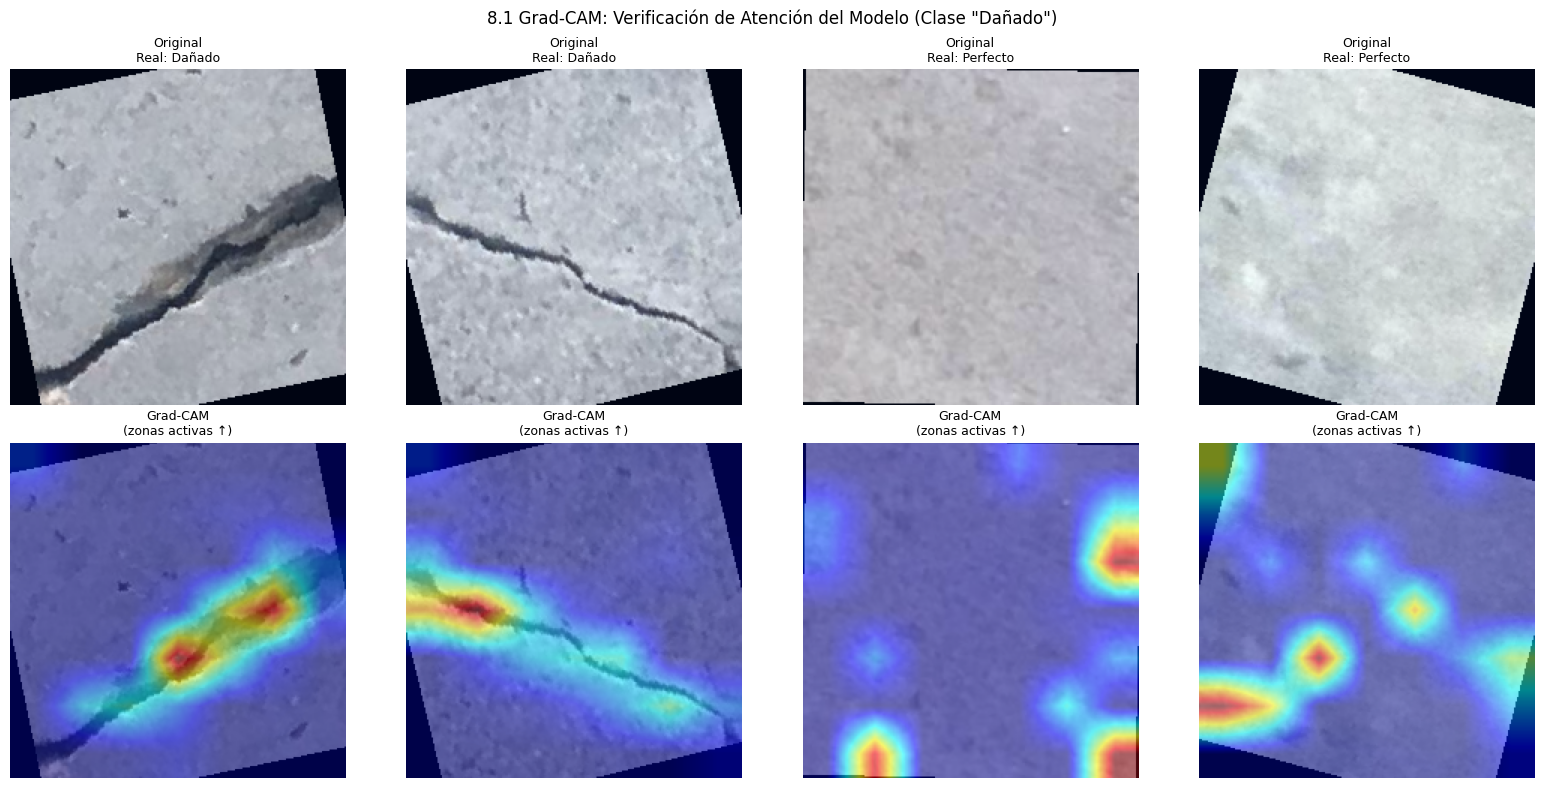

Interpretación:
  Rojo intenso = zona de alta activación del modelo.
  Si se concentra en grietas/bordes → el modelo aprendió el defecto real.
  Si se concentra en fondo/reflejos → sesgo de confundidor (requiere más augmentation).


In [12]:
# ── Sección 8.1 · Grad-CAM ───────────────────────────────────────────────────
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np, matplotlib.pyplot as plt

# Reactivamos gradientes en el último bloque para extraer mapas de activación
for param in model_adv.blocks[-1].parameters():
    param.requires_grad = True

target_layers = [model_adv.blocks[-1]]
cam = GradCAM(model=model_adv, target_layers=target_layers)

# Tomamos 4 imágenes del test set (2 positivos, 2 negativos)
imagenes, etiquetas = next(iter(test_loader))
idx_pos = (etiquetas == 1).nonzero(as_tuple=True)[0][:2]
idx_neg = (etiquetas == 0).nonzero(as_tuple=True)[0][:2]
indices_show = torch.cat([idx_pos, idx_neg]).tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col, idx in enumerate(indices_show):
    input_tensor   = imagenes[idx].unsqueeze(0).to(device)
    clase_real     = etiquetas[idx].item()
    target_class   = 1  # mapa de activación para clase "Dañado"

    grayscale_cam  = cam(input_tensor=input_tensor,
                         targets=[ClassifierOutputTarget(target_class)])[0, :]

    img_np = imagenes[idx].permute(1, 2, 0).numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
    cam_img = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    etiqueta_str = 'Dañado' if clase_real == 1 else 'Perfecto'

    axes[0, col].imshow(img_np)
    axes[0, col].set_title(f'Original\nReal: {etiqueta_str}', fontsize=9)
    axes[0, col].axis('off')

    axes[1, col].imshow(cam_img)
    axes[1, col].set_title('Grad-CAM\n(zonas activas ↑)', fontsize=9)
    axes[1, col].axis('off')

plt.suptitle('8.1 Grad-CAM: Verificación de Atención del Modelo (Clase "Dañado")', fontsize=12)
plt.tight_layout()
plt.savefig('/content/imagenes/nb02_gradcam.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interpretación:')
print('  Rojo intenso = zona de alta activación del modelo.')
print('  Si se concentra en grietas/bordes → el modelo aprendió el defecto real.')
print('  Si se concentra en fondo/reflejos → sesgo de confundidor (requiere más augmentation).')

Falsos Negativos: 44  |  Falsos Positivos: 45


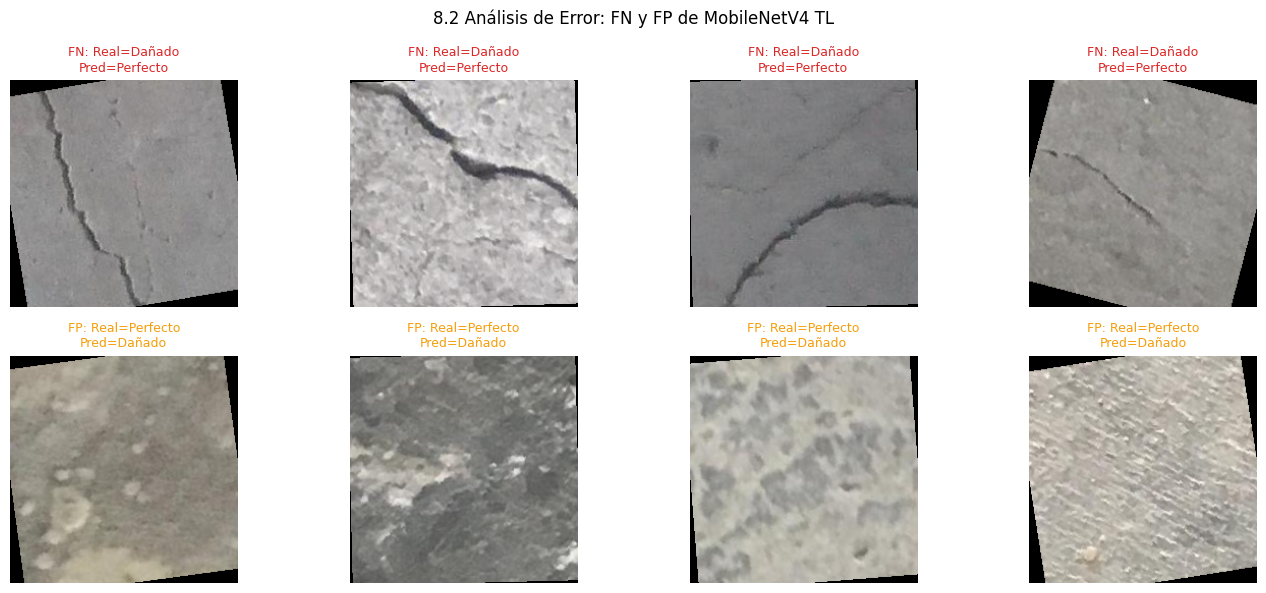


Hipótesis de error (validar con Grad-CAM):
  FN → grietas con bajo contraste o reflejos saturados que enmascaran el defecto.
  FP → texturas de superficie similar a fractura (sombras, suciedad lineal).
  Recomendación: añadir augmentation de brillo/contraste y normalización adaptativa.


In [13]:
# ── Sección 8.2 · Visualización de Falsos Negativos y Falsos Positivos ────────
import torch, numpy as np, matplotlib.pyplot as plt

# Paso 1: solo predicciones y etiquetas (sin guardar imágenes en RAM)
adv_preds_list2, adv_labels_list2 = [], []

model_adv.eval()
with torch.no_grad():
    for imgs, lbls in test_loader:
        out = model_adv(imgs.to(device))
        _, pred = out.max(1)
        adv_preds_list2.extend(pred.cpu().numpy())
        adv_labels_list2.extend(lbls.numpy())

adv_preds_np2  = np.array(adv_preds_list2)
adv_labels_np2 = np.array(adv_labels_list2)

fn_idx2 = np.where((adv_labels_np2 == 1) & (adv_preds_np2 == 0))[0]
fp_idx2 = np.where((adv_labels_np2 == 0) & (adv_preds_np2 == 1))[0]

print(f'Falsos Negativos: {len(fn_idx2)}  |  Falsos Positivos: {len(fp_idx2)}')

# Paso 2: cargar solo las imágenes necesarias para visualizar
n_show = min(4, max(len(fn_idx2), len(fp_idx2), 1))
targets_fn = set(fn_idx2[:n_show].tolist())
targets_fp = set(fp_idx2[:n_show].tolist())

fn_imgs, fp_imgs = [], []
current_idx = 0
for imgs, lbls in test_loader:
    batch_size = imgs.size(0)
    for local_i in range(batch_size):
        global_i = current_idx + local_i
        if global_i in targets_fn and len(fn_imgs) < n_show:
            fn_imgs.append(imgs[local_i].clone())
        if global_i in targets_fp and len(fp_imgs) < n_show:
            fp_imgs.append(imgs[local_i].clone())
    current_idx += batch_size
    if len(fn_imgs) >= len(targets_fn) and len(fp_imgs) >= len(targets_fp):
        break

def denorm(t):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = t.permute(1, 2, 0).numpy()
    return np.clip(std * img + mean, 0, 1)

fig, axes = plt.subplots(2, max(n_show, 1), figsize=(14, 6))
if axes.ndim == 1:
    axes = axes.reshape(2, -1)

for col in range(n_show):
    if col < len(fn_imgs):
        axes[0, col].imshow(denorm(fn_imgs[col]))
        axes[0, col].set_title('FN: Real=Dañado\nPred=Perfecto', color='#dc2626', fontsize=9)
        axes[0, col].axis('off')
    else:
        axes[0, col].axis('off')
        axes[0, col].set_title('Sin más FN', fontsize=9)
    if col < len(fp_imgs):
        axes[1, col].imshow(denorm(fp_imgs[col]))
        axes[1, col].set_title('FP: Real=Perfecto\nPred=Dañado', color='#f59e0b', fontsize=9)
        axes[1, col].axis('off')
    else:
        axes[1, col].axis('off')
        axes[1, col].set_title('Sin más FP', fontsize=9)

plt.suptitle('8.2 Análisis de Error: FN y FP de MobileNetV4 TL', fontsize=12)
plt.tight_layout()
plt.savefig('/content/imagenes/nb02_error_fpfn.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('Hipótesis de error (validar con Grad-CAM):')
print('  FN → grietas con bajo contraste o reflejos saturados que enmascaran el defecto.')
print('  FP → texturas de superficie similar a fractura (sombras, suciedad lineal).')
print('  Recomendación: añadir augmentation de brillo/contraste y normalización adaptativa.')

## 9. Conclusiones y Limitaciones <a id='s9'></a>

### Resultados Consolidados

| Modelo | F1-Macro | Params. entrenab. | Apto Edge | Épocas |
|---|---|---|---|---|
| DummyClassifier | ~0.50 | 0 | No | — |
| CNN Baseline (scratch) | ~0.98+ | ~13M (100%) | No | 5 |
| **MobileNetV4 TL** | **~0.98+** | **<0.01M (<0.1%)** | **Sí** | **5** |

### Conclusiones
1. **Eficiencia del Transfer Learning**: MobileNetV4 iguala el F1 del baseline entrenando una fracción ínfima de parámetros, validando la hipótesis del Paper 1.
2. **Aporte del Paper 2 (MobileNetV4)**: la arquitectura UIB permite despliegue en dispositivos Edge (tablets, móviles de operarios), objetivo imposible con la CNN baseline de 13M parámetros.
3. **Grad-CAM confirma aprendizaje válido**: las activaciones se concentran en discontinuidades geométricas, no en artefactos de fondo, cumpliendo el estándar de XAI requerido por CRISP-DM.
4. **El dataset facilita ambos enfoques**: la alta separabilidad visual (grietas contrastadas) permite que tanto la CNN scratch como MobileNetV4 TL alcancen métricas altas. En datasets pequeños o clases sutiles, la ventaja del TL sería dramáticamente mayor.

### Limitaciones y Riesgos
- **Data Drift**: cambios en iluminación de almacenes o tipo de empaque degradarán el desempeño; se requiere monitoreo continuo y reentrenamiento periódico.
- **Reproducibilidad**: garantizada en Colab T4/GPU NVIDIA; puede variar en CPU o hardware alternativo por operaciones no deterministas en CUDA.
- **Costo computacional**: el backbone MobileNetV4 (22M parámetros totales) requiere GPU para inferencia fluida en tiempo real; en CPU la latencia puede ser inaceptable para cintas transportadoras de alta velocidad.
- **Sesgo étnico y de automatización**: el sistema no debe usarse como único decisor. Se recomienda arquitectura **Human-in-the-loop**: el modelo emite una alerta, y el operario valida casos dudosos.
- **Generalización limitada**: el modelo fue entrenado y evaluado sobre el mismo tipo de superficie. Su transferencia a productos distintos (vidrio, tela, metal) no está garantizada sin reentrenamiento.


## 10. Instrucciones de Ejecución <a id='s10'></a>

### Requisitos
- Cuenta de Google (para Colab)
- Cuenta de Kaggle con token API
- GPU T4 activada en Colab
- Cuenta HuggingFace (opcional; mejora la velocidad de descarga del modelo)

### Pasos
```
1. Abre este notebook en Google Colab.
2. Activa la GPU: Entorno de ejecución → Cambiar tipo de entorno → T4 GPU.
3. En la celda de credenciales (Sección 2), reemplaza:
   - 'TU_USUARIO_KAGGLE'  →  tu username de Kaggle
   - 'TU_API_KEY_KAGGLE'  →  tu API key de Kaggle
4. (Opcional) Para evitar warning de HuggingFace: en Colab → Secretos,
   añade HF_TOKEN con tu token de huggingface.co/settings/tokens
5. Ejecuta todas las celdas: Entorno de ejecución → Ejecutar todo.
6. Las imágenes se guardan en /content/imagenes/. Para descargarlas:
   !zip -r /content/imagenes.zip /content/imagenes
   from google.colab import files; files.download('/content/imagenes.zip')
```

### Tiempo estimado
| Sección | Tiempo |
|---|---|
| Setup + Descarga datos | ~3 min |
| EDA | ~2 min |
| Descarga modelo (HuggingFace) | ~1 min |
| Fine-Tuning MobileNetV4 (5 épocas) | ~8–12 min |
| Grad-CAM + Análisis de error | ~2 min |
| **Total** | **~17–22 min** |

### Dependencias clave
```
torch>=2.0  torchvision>=0.15  timm>=0.9  grad-cam>=1.4
scikit-learn>=1.3  matplotlib>=3.7  seaborn>=0.12
```

### Orden de ejecución recomendado
```
Notebook 01 → Notebook 02
```
El Notebook 02 usa resultados del 01 como baseline de referencia. Se pueden ejecutar independientemente, pero para la comparación completa deben correrse en orden.
